In [1]:
import os
import pandas as pd
from skimage.feature import hog
from skimage.color import rgb2gray, rgb2hsv
from skimage.transform import resize
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models
import joblib

2026-05-16 13:18:48.831736: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 13:18:48.850596: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
# Importing models
cnn_full = tf.keras.models.load_model("cnn_model.keras")
cnn_bbox = tf.keras.models.load_model("cnn_model_box.keras")

In [8]:
# Create dataframes from dataset files
DATA_DIR = "CUB_200_2011"
IMAGES_DIR = os.path.join(DATA_DIR, "images")

# Load the metadata files
images_df = pd.read_csv(
    os.path.join(DATA_DIR, "images.txt"),
    sep=" ",
    names=["image_id", "image_path"]
)

labels_df = pd.read_csv(
    os.path.join(DATA_DIR, "image_class_labels.txt"),
    sep=" ",
    names=["image_id", "class_id"]
)

bbox_df = pd.read_csv(
    os.path.join(DATA_DIR, "bounding_boxes.txt"),
    sep=" ",
    names=["image_id", "x", "y", "width", "height"]
)

splt_df = pd.read_csv(
    os.path.join(DATA_DIR, "train_test_split.txt"),
    sep=" ",
    names=["image_id", "is_train"]
)

# Merge all the dataframes into a single frame called 'data'
data = images_df.merge(labels_df, on="image_id").merge(bbox_df, on="image_id").merge(splt_df, on="image_id")

unique_classes = sorted(data["class_id"].unique())
print(f"Number of unique classes: {len(unique_classes)}")

class_mapping = {old: new for new, old in enumerate(unique_classes)}

data["label"] = data["class_id"].map(class_mapping)

data["full_path"] = data["image_path"].apply(
    lambda x: os.path.join(IMAGES_DIR, x)
)

# Split data into training and testing sets
train_df = data[data["is_train"] == 1].reset_index(drop=True)
test_df = data[data["is_train"] == 0].reset_index(drop=True)

train_paths = train_df["full_path"].values
train_labels = train_df["label"].values
train_bboxes = train_df[["x", "y", "width", "height"]].values

test_paths = test_df["full_path"].values
test_labels = test_df["label"].values
test_bboxes = test_df[["x", "y", "width", "height"]].values

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))
print("Number of classes:", data["label"].nunique())

# Calculate most common size size of images in the dataset
most_common_width = int(data["image_path"].apply(lambda x: Image.open(os.path.join(IMAGES_DIR, x)).size[0]).mode()[0])
most_common_height = int(data["image_path"].apply(lambda x: Image.open(os.path.join(IMAGES_DIR, x)).size[1]).mode()[0])
most_common_size = (most_common_width, most_common_height)
print(f"Most common image size: {most_common_size}")

# While the most common size is (500, 500), I run out of RAM, so we'll need to need to resize the images to a smaller size like (300, 300)
most_common_size = (160, 160)


# Resize the image to a fixed size for consistent feature extraction
def resizeImage(image, target_size):
    return resize(image, target_size)


Number of unique classes: 200
Training samples: 5994
Testing samples: 5794
Number of classes: 200
Most common image size: (500, 500)


In [9]:


# Build CNN test datasets
def build_cnn_dataset(paths, labels, avg_size):
    X, y = [], []
    for p, l in tqdm.tqdm(zip(paths, labels), total=len(paths), desc="Building CNN dataset"):
        image = Image.open(p).convert("RGB")
        image = np.array(image)
        image_data = resizeImage(image, avg_size)
        X.append(image_data)
        y.append(l)
    return np.array(X), np.array(y)

def build_boundingbox_cnn_dataset(paths, labels, bboxes, avg_size):
    X, y = [], []
    for p, l, bbox in tqdm.tqdm(zip(paths, labels, bboxes), total=len(paths), desc="Building CNN bbox dataset"):
        image = Image.open(p).convert("RGB")
        image = np.array(image)
        
        x, y_coord, width, height = bbox
        x, y_coord, width, height = int(x), int(y_coord), int(width), int(height)
        
        x = max(0, x)
        y_coord = max(0, y_coord)
        x_end = min(image.shape[1], x + width)
        y_end = min(image.shape[0], y_coord + height)
        
        image_cropped = image[y_coord:y_end, x:x_end]
        image_data = resizeImage(image_cropped, avg_size)
        
        X.append(image_data)
        y.append(l)
    
    return np.array(X), np.array(y)

# Build CNN test datasets (no transformation needed - CNN handles normalization)
print("\nBuilding CNN test datasets...")
X_test_cnn_full, _ = build_cnn_dataset(test_paths, test_labels, avg_size=most_common_size)
X_test_cnn_bbox, _ = build_boundingbox_cnn_dataset(test_paths, test_labels, test_bboxes, avg_size=most_common_size)

print(f"CNN test dataset shape (full): {X_test_cnn_full.shape}")
print(f"CNN test dataset shape (bbox): {X_test_cnn_bbox.shape}")

# Create confusion matrix and classification report
def evaluate_model(model_name, model, X_test, y_test, is_cnn=False):
    from sklearn.metrics import confusion_matrix, classification_report
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print(f"{'='*60}")
    y_pred = model.predict(X_test)
    if is_cnn:
        y_pred = np.argmax(y_pred, axis=1)
    return y_pred

print("\n" + "="*80)
print("GENERATING EVALUATION METRICS FOR ALL 4 MODELS")
print("="*80)

# Evaluate all models
pred_cnn_full = evaluate_model("CNN (Full Image)", cnn_full, X_test_cnn_full, test_labels, is_cnn=True)
pred_cnn_bbox = evaluate_model("CNN (Bounding Box)", cnn_bbox, X_test_cnn_bbox, test_labels, is_cnn=True)



Building CNN test datasets...


Building CNN bbox dataset: 100%|██████████| 5794/5794 [00:28<00:00, 204.26it/s]


CNN test dataset shape (full): (5794, 160, 160, 3)
CNN test dataset shape (bbox): (5794, 160, 160, 3)

GENERATING EVALUATION METRICS FOR ALL 4 MODELS

Evaluating CNN (Full Image)
182/182 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step

Evaluating CNN (Bounding Box)
182/182 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step


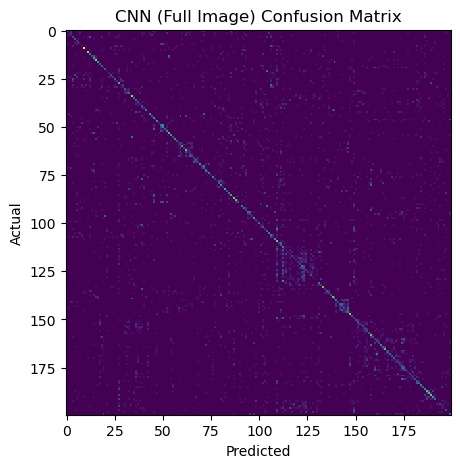

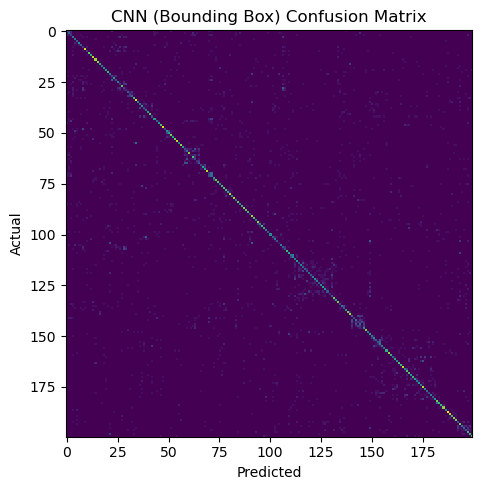

In [10]:

# Use matplotlib to visualize some predictions
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Draw confusion matrices and classification reports for all models

plt.figure(figsize=(15, 5))

# Plot confusion matrix for CNN (Full Image)

plt.imshow(confusion_matrix(test_labels, pred_cnn_full), interpolation='nearest')
plt.title('CNN (Full Image) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
# Plot confusion matrix for CNN (Bounding Box)
plt.figure(figsize=(15, 5))
plt.imshow(confusion_matrix(test_labels, pred_cnn_bbox), interpolation='nearest')
plt.title('CNN (Bounding Box) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


In [11]:

# Detailed accuracy analysis by class
from sklearn.metrics import accuracy_score

# Get class names from the dataset
classes_df = pd.read_csv(os.path.join(DATA_DIR, "classes.txt"), sep=" ", names=["class_id", "class_name"], header=None)
class_id_to_name = dict(zip(classes_df["class_id"] - 1, classes_df["class_name"]))  # -1 because class_ids are 1-indexed

def analyze_accuracy(model_name, y_true, y_pred):
    """Analyze overall and per-class accuracy"""
    from sklearn.metrics import accuracy_score, recall_score
    
    print(f"\n{'='*80}")
    print(f"DETAILED ACCURACY ANALYSIS: {model_name}")
    print(f"{'='*80}")
    
    # Global accuracy
    global_acc = accuracy_score(y_true, y_pred)
    print(f"\nGlobal Accuracy: {global_acc:.4f} ({global_acc*100:.2f}%)")
    
    # Per-class accuracy (recall)
    per_class_acc = recall_score(y_true, y_pred, average=None, zero_division=0)
    
    # Create a list of (class_idx, class_name, accuracy)
    class_performance = []
    for class_idx in range(len(per_class_acc)):
        class_name = class_id_to_name.get(class_idx, f"Class_{class_idx}")
        class_performance.append((class_idx, class_name, per_class_acc[class_idx]))
    
    # Sort by accuracy
    class_performance_sorted = sorted(class_performance, key=lambda x: x[2], reverse=True)
    
    # Top 3 performers
    print(f"\n{'─'*80}")
    print("TOP 3 BEST PERFORMING CLASSES:")
    print(f"{'─'*80}")
    for i, (class_idx, class_name, acc) in enumerate(class_performance_sorted[:3], 1):
        print(f"{i}. {class_name:40s} | Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    # Bottom 3 performers
    print(f"\n{'─'*80}")
    print("TOP 3 WORST PERFORMING CLASSES:")
    print(f"{'─'*80}")
    for i, (class_idx, class_name, acc) in enumerate(class_performance_sorted[-3:][::-1], 1):
        print(f"{i}. {class_name:40s} | Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    print(f"\n{'='*80}\n")
    
    return global_acc, per_class_acc, class_performance_sorted

# Analyze both CNN models
cnn_full_global, cnn_full_per_class, cnn_full_sorted = analyze_accuracy("CNN Full Image", test_labels, pred_cnn_full)
cnn_bbox_global, cnn_bbox_per_class, cnn_bbox_sorted = analyze_accuracy("CNN Bounding Box", test_labels, pred_cnn_bbox)



DETAILED ACCURACY ANALYSIS: CNN Full Image

Global Accuracy: 0.2432 (24.32%)

────────────────────────────────────────────────────────────────────────────────
TOP 3 BEST PERFORMING CLASSES:
────────────────────────────────────────────────────────────────────────────────
1. 010.Red_winged_Blackbird                 | Accuracy: 0.7333 (73.33%)
2. 012.Yellow_headed_Blackbird              | Accuracy: 0.7308 (73.08%)
3. 007.Parakeet_Auklet                      | Accuracy: 0.6522 (65.22%)

────────────────────────────────────────────────────────────────────────────────
TOP 3 WORST PERFORMING CLASSES:
────────────────────────────────────────────────────────────────────────────────
1. 199.Winter_Wren                          | Accuracy: 0.0000 (0.00%)
2. 193.Bewick_Wren                          | Accuracy: 0.0000 (0.00%)
3. 131.Vesper_Sparrow                       | Accuracy: 0.0000 (0.00%)



DETAILED ACCURACY ANALYSIS: CNN Bounding Box

Global Accuracy: 0.4955 (49.55%)

─────────────────────